In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Проект: Анализ пользовательского поведения образовательной платформы")

Проект: Анализ пользовательского поведения образовательной платформы


In [12]:
users = pd.DataFrame({
    "user_id": range(1, 11),
    "age": [22,25,31,28,35,21,29,40,33,26],
    "source": [
        "Google",
        "VK",
        "Google",
        "Organic",
        "VK",
        "Google",
        "Organic",
        "VK",
        "Google",
        "Organic"
    ]
})

users

,user_id,age,source
0,1,22,Google
1,2,25,VK
2,3,31,Google
3,4,28,Organic
4,5,35,VK
5,6,21,Google
6,7,29,Organic
7,8,40,VK
8,9,33,Google
9,10,26,Organic


In [13]:
events = pd.DataFrame({
    "user_id": [
        1,1,1,
        2,
        3,3,3,
        4,
        5,5,
        6,
        7,7,7,
        8,
        9,9,
        10
    ],
    "event": [
        "signup",
        "start_course",
        "complete_lesson",

        "signup",

        "signup",
        "start_course",
        "complete_lesson",

        "signup",

        "signup",
        "start_course",

        "signup",

        "signup",
        "start_course",
        "complete_lesson",

        "signup",

        "signup",
        "start_course",

        "signup"
    ]
})

events

,user_id,event
0,1,signup
1,1,start_course
2,1,complete_lesson
3,2,signup
4,3,signup
5,3,start_course
6,3,complete_lesson
7,4,signup
8,5,signup
9,5,start_course


In [14]:


registrations = users["user_id"].nunique()

started = events[
    events["event"] == "start_course"
]["user_id"].nunique()

completed = events[
    events["event"] == "complete_lesson"
]["user_id"].nunique()


print("Регистрации:", registrations)
print("Начали курс:", started)
print("Закончили первый урок:", completed)

Регистрации: 10
Начали курс: 5
Закончили первый урок: 3


In [15]:
funnel = pd.DataFrame({
    "Этап": [
        "Регистрация",
        "Начало курса",
        "Первый урок"
    ],
    "Пользователи": [
        registrations,
        started,
        completed
    ]
})

funnel

,Этап,Пользователи
0,Регистрация,10
1,Начало курса,5
2,Первый урок,3


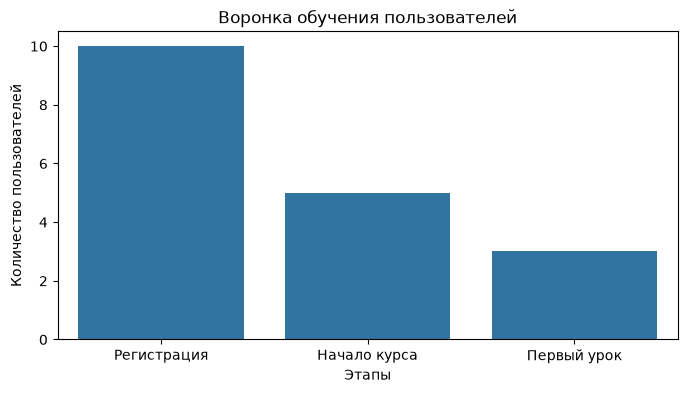

In [20]:
plt.figure(figsize=(8,4))

sns.barplot(
    data=funnel,
    x="Этап",
    y="Пользователи"
)

plt.title("Воронка обучения пользователей")
plt.ylabel("Количество пользователей")
plt.xlabel("Этапы")

plt.show()

In [21]:


source_analysis = users.groupby("source")["user_id"].count().reset_index()

source_analysis.columns = ["Источник", "Количество пользователей"]

source_analysis

,Источник,Количество пользователей
0,Google,4
1,Organic,3
2,VK,3


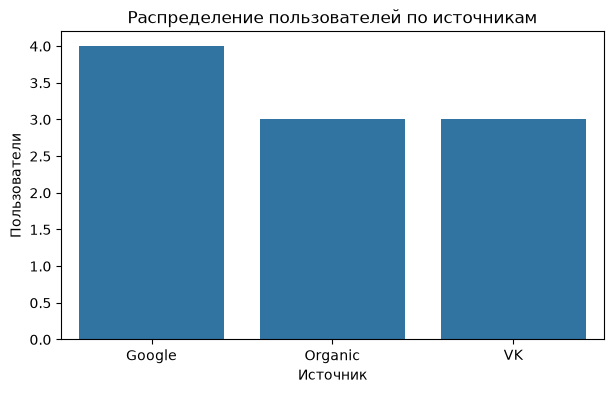

In [22]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=source_analysis,
    x="Источник",
    y="Количество пользователей"
)

plt.title("Распределение пользователей по источникам")
plt.xlabel("Источник")
plt.ylabel("Пользователи")

plt.show()

# Анализ пользовательского поведения образовательной платформы

## Цель проекта
Исследовать путь пользователя от регистрации до начала обучения и определить этапы, где происходит наибольшая потеря пользователей.

## Использованные инструменты
- Python
- Pandas
- Matplotlib
- Seaborn

## Основные результаты

- Всего зарегистрировалось: 10 пользователей.
- Начали обучение: 5 пользователей.
- Завершили первый урок: 3 пользователя.

Конверсия из регистрации в начало курса составила 50%.

## Выводы

Основная потеря пользователей происходит между регистрацией и началом обучения. Это может указывать на проблемы первого пользовательского опыта (onboarding).

Рекомендуется:
- улучшить первый экран после регистрации;
- добавить подсказки по началу обучения;
- протестировать разные варианты приветственного сценария.

Дополнительно был проведён анализ источников привлечения пользователей. Для полной оценки каналов необходимо сравнить не только количество регистраций, но и качество пользователей по дальнейшим действиям.